In [1]:
import os
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, Trainer, TrainingArguments, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from datasets import load_dataset
import json
import matplotlib.pyplot as plt
import numpy as np
import statistics
import sys
import seaborn as sns
sys.path.append('..')
from style_setup import set_thesis_style
set_thesis_style()

# Analyzing finetuning process

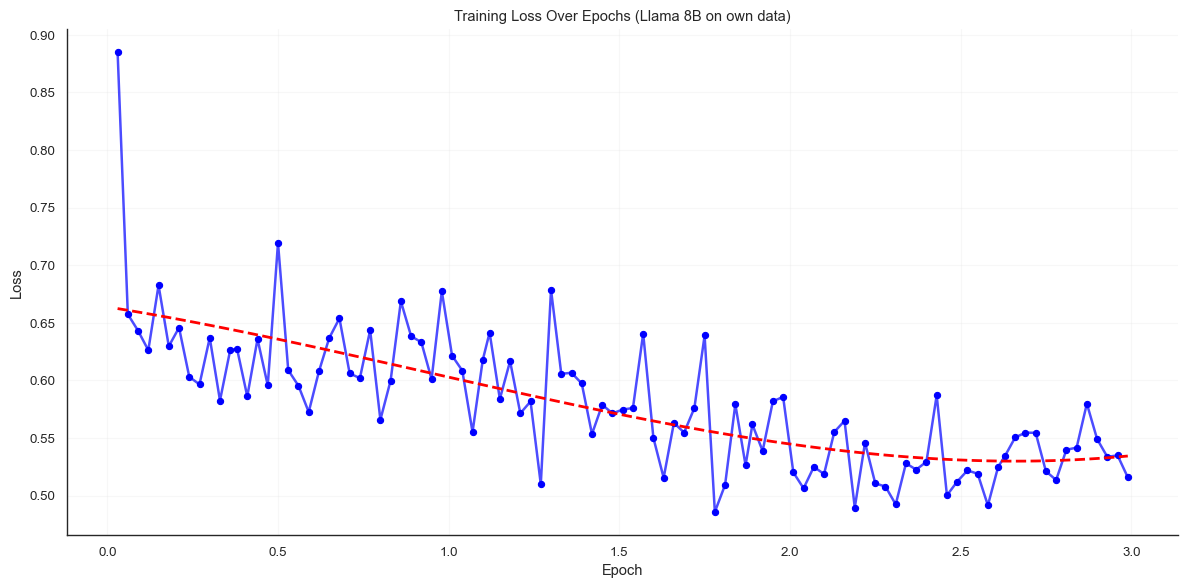

Initial loss: 0.8851
Final loss: 0.5158
Minimum loss: 0.4858 at epoch 1.78
Loss reduction: 45.11%


In [12]:
# Read the finetuning_output.jsonl file
output_file = "finetuning_logs/llama8b_single_log1.jsonl"
losses = []
epochs = []

with open(output_file, 'r') as f:
    for line in f:
        try:
            data = json.loads(line)
            losses.append(data['loss'])
            epochs.append(data['epoch'])
        except json.JSONDecodeError:
            print(f"Error parsing line: {line}")
        except KeyError:
            print(f"Missing key in line: {line}")

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(epochs, losses, 'b-', alpha=0.7)
plt.scatter(epochs, losses, c='blue', s=20)

# Add smoothed trend line
if len(losses) > 10:
    z = np.polyfit(epochs, losses, 3)
    p = np.poly1d(z)
    plt.plot(epochs, p(epochs), 'r--', linewidth=2)

plt.title('Training Loss Over Epochs (Llama 8B on own data)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

# Add annotations for min and max loss
min_loss = min(losses)
min_epoch = epochs[losses.index(min_loss)]
max_loss = max(losses)
max_epoch = epochs[losses.index(max_loss)]

'''
plt.annotate(f'Min Loss: {min_loss:.4f}', 
             xy=(min_epoch, min_loss),
             xytext=(min_epoch, min_loss+0.05),
             arrowprops=dict(facecolor='green', shrink=0.05),
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="green", alpha=0.8))

plt.annotate(f'Max Loss: {max_loss:.4f}', 
             xy=(max_epoch, max_loss),
             xytext=(max_epoch, max_loss-0.1),
             arrowprops=dict(facecolor='red', shrink=0.05),
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8))
'''


plt.tight_layout()
plt.show()

print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss: {losses[-1]:.4f}")
print(f"Minimum loss: {min_loss:.4f} at epoch {min_epoch:.2f}")
print(f"Loss reduction: {((losses[0] - min_loss) / losses[0] * 100):.2f}%")


## Check how much data is >2048 tokens

In [22]:
# Load the tokenizer for Llama
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct")

# Path to the jsonl file
#file_path = "../../Data/Finetuning/Augmented/Small/Llama/dolly_train_all_Llama.jsonl"
#file_path = "../../Data/Finetuning/Augmented/Small/Other/dolly_train_all_multi.jsonl"
#file_path = "../../Data/Finetuning/Augmented/Medium/Llama/dolly_train_all_Llama.jsonl"
file_path = "../../Data/Finetuning/Augmented/Medium/Other/dolly_train_all_multi.jsonl"

# Check if the file exists
if not os.path.exists(file_path):
    print(f"File not found: {file_path}")
else:
    # Count total entries and those exceeding token limit
    total_entries = 0
    exceeding_limit = 0
    max_tokens = 0
    total_instruction_tokens_exceeding = 0
    instruction_token_lengths = []
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            total_entries += 1
            data = json.loads(line)
            
            # Find the appropriate response key (not using response_human)
            response_key = next((key for key in data.keys() 
                               if key.startswith("response_") and key != "response_human"), 
                              "response")  # fallback to "response" if no matching key found
            
            # Tokenize instruction and combined text separately
            instruction_text = data['instruction']
            instruction_tokens = tokenizer.encode(instruction_text)
            instruction_token_count = len(instruction_tokens)
            
            combined_text = f"You are a helpful assistant.\nInstruction: {data['instruction']}\nResponse: {data[response_key]}"
            tokens = tokenizer.encode(combined_text)
            token_count = len(tokens)
            
            # Update max token count
            max_tokens = max(max_tokens, token_count)
            
            # Check if token count exceeds limit
            if token_count > 2048:
                exceeding_limit += 1
                total_instruction_tokens_exceeding += instruction_token_count
                instruction_token_lengths.append(instruction_token_count)
    
    # Calculate percentages and averages
    percentage = (exceeding_limit / total_entries) * 100 if total_entries > 0 else 0
    avg_instruction_tokens = total_instruction_tokens_exceeding / exceeding_limit if exceeding_limit > 0 else 0
    median_instruction_tokens = statistics.median(instruction_token_lengths) if instruction_token_lengths else 0
    
    print(f"Total entries: {total_entries}")
    print(f"Entries exceeding 2048 tokens: {exceeding_limit} ({percentage:.2f}%)")
    print(f"Maximum token count found: {max_tokens}")
    print(f"Average instruction length for entries exceeding limit: {avg_instruction_tokens:.2f} tokens")
    print(f"Median instruction length for entries exceeding limit: {median_instruction_tokens:.2f} tokens")


Total entries: 13509
Entries exceeding 2048 tokens: 30 (0.22%)
Maximum token count found: 6216
Average instruction length for entries exceeding limit: 2863.77 tokens
Median instruction length for entries exceeding limit: 2448.00 tokens


# Analyze new finetuning run

In [15]:
# Load the trainer state from the checkpoint
#final_checkpoint_path = "/Volumes/ExtremeSSD/Master/Thesis/Data/ft_models/lora_llama_8b_single_v6/checkpoint-1684/trainer_state.json"
#final_checkpoint_path = "/Users/maxschaffelder/Desktop/Thesis/Data/ft_stats/trainer_state_8b_multi_v1.json"
#final_checkpoint_path = "/Users/maxschaffelder/Desktop/Thesis/Data/ft_stats/trainer_state_8b_human_v1.json"
#final_checkpoint_path = "/Users/maxschaffelder/Desktop/Thesis/Data/ft_stats/trainer_state_70b_single_v1.json"
#final_checkpoint_path = "/Users/maxschaffelder/Desktop/Thesis/Data/ft_stats/trainer_state_70b_single_v2.json"#
final_checkpoint_path = "/Users/maxschaffelder/Desktop/Thesis/Data/ft_stats/trainer_state_8b_human_v3.json"
#final_checkpoint_path = "/Users/maxschaffelder/Desktop/Thesis/data/ft_stats/trainer_state_8b_multi_v3.json"
#final_checkpoint_path = "/Users/maxschaffelder/Desktop/Thesis/Data/ft_stats/trainer_state_8b_single_v8.json"

with open(final_checkpoint_path, 'r') as f:
    trainer_state = json.load(f)

log_hist = trainer_state['log_history']

# Create a DataFrame from the log history
log_df = pd.DataFrame(log_hist)

log_df.head(10)

,epoch,grad_norm,learning_rate,loss,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,0.059312,5.663138,0.000006,13.8438,50,NaN,NaN,NaN,NaN
1,0.118624,1.192833,0.000010,12.2560,100,NaN,NaN,NaN,NaN
2,0.177936,0.295223,0.000010,11.6408,150,NaN,NaN,NaN,NaN
3,0.237248,0.278166,0.000009,11.5620,200,NaN,NaN,NaN,NaN
4,0.237248,NaN,NaN,NaN,200,11.525683,186.1965,8.056,0.505
5,0.296560,0.140783,0.000009,11.4921,250,NaN,NaN,NaN,NaN
6,0.355872,0.140187,0.000008,11.4944,300,NaN,NaN,NaN,NaN
7,0.415184,0.137705,0.000007,11.5114,350,NaN,NaN,NaN,NaN
8,0.474496,0.146317,0.000006,11.4590,400,NaN,NaN,NaN,NaN
9,0.474496,NaN,NaN,NaN,400,11.478430,185.9256,8.068,0.506


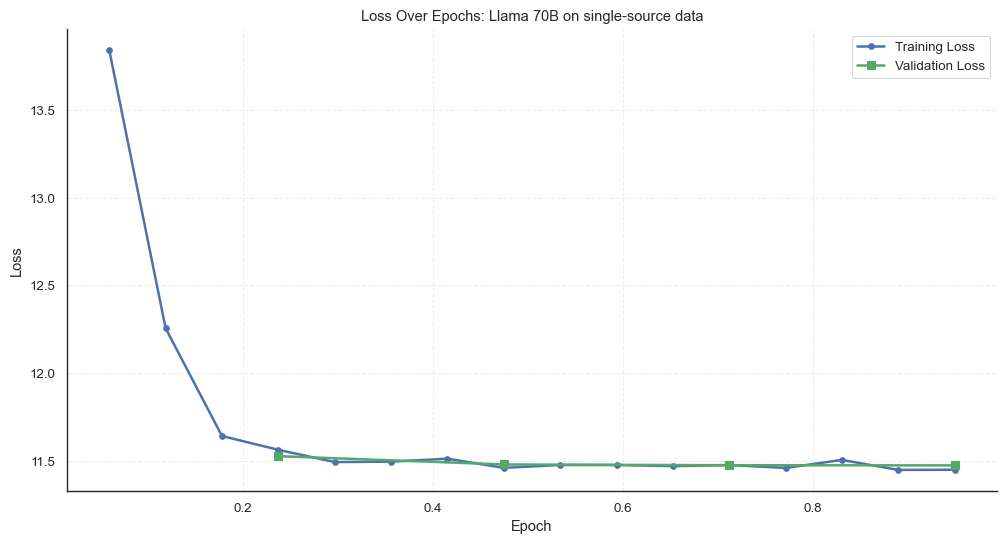

In [16]:
# Plot both training and validation loss on the same figure
plt.figure(figsize=(12, 6))

# Filter out NaN values before plotting
filtered_df_loss = log_df.dropna(subset=['loss'])
filtered_df_eval_loss = log_df.dropna(subset=['eval_loss'])

# Plot training loss
#plt.plot(filtered_df_loss['step'], filtered_df_loss['loss'], label='Training Loss', marker='o', markersize=4)
plt.plot(filtered_df_loss['epoch'], filtered_df_loss['loss'], label='Training Loss', marker='o', markersize=4)

# Plot validation loss
#plt.plot(filtered_df_eval_loss['step'], filtered_df_eval_loss['eval_loss'], label='Validation Loss', marker='s', markersize=6)
plt.plot(filtered_df_eval_loss['epoch'], filtered_df_eval_loss['eval_loss'], label='Validation Loss', marker='s', markersize=6)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs: Llama 70B on single-source data')
#plt.yscale('log')
#plt.xlim(200, 1263)
#plt.ylim(10.25, 10.75)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
#plt.savefig('../plots/finetuning/loss_over_epochs_llama8b_multi_v1.png', dpi=300)
plt.show()

In [18]:
# Get the final training and evaluation loss
final_train_loss = filtered_df_loss['loss'].iloc[-1]
final_eval_loss = filtered_df_eval_loss['eval_loss'].iloc[-1]

print(f"Final training loss: {final_train_loss:.6f}")
print(f"Final evaluation loss: {final_eval_loss:.6f}")

# Calculate the difference between training and evaluation loss
loss_difference = final_train_loss - final_eval_loss
print(f"Difference (train - eval): {loss_difference:.6f}")


Final training loss: 11.459700
Final evaluation loss: 11.488346
Difference (train - eval): -0.028646


In [19]:
# Print all evaluation loss values
print("All evaluation loss values:")
eval_losses = log_df.dropna(subset=['eval_loss'])[['step', 'epoch', 'eval_loss']]
for index, row in eval_losses.iterrows():
    print(f"Step: {row['step']}, Epoch: {row['epoch']:.6f}, Eval Loss: {row['eval_loss']:.6f}")

# Calculate statistics on evaluation loss
print("\nEvaluation Loss Statistics:")
print(f"Mean: {eval_losses['eval_loss'].mean():.6f}")
print(f"Min: {eval_losses['eval_loss'].min():.6f}")
print(f"Max: {eval_losses['eval_loss'].max():.6f}")
print(f"Standard Deviation: {eval_losses['eval_loss'].std():.6f}")


All evaluation loss values:
Step: 200.0, Epoch: 0.237248, Eval Loss: 11.796147
Step: 400.0, Epoch: 0.474496, Eval Loss: 11.551917
Step: 600.0, Epoch: 0.711744, Eval Loss: 11.513860
Step: 800.0, Epoch: 0.948992, Eval Loss: 11.501112
Step: 1000.0, Epoch: 1.186240, Eval Loss: 11.494034
Step: 1200.0, Epoch: 1.423488, Eval Loss: 11.490356
Step: 1400.0, Epoch: 1.660735, Eval Loss: 11.488748
Step: 1600.0, Epoch: 1.897983, Eval Loss: 11.488346

Evaluation Loss Statistics:
Mean: 11.540565
Min: 11.488346
Max: 11.796147
Standard Deviation: 0.105437
